In [1]:
import os
import sys
import matplotlib

import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import tacco as tc

# Variables

In [2]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'
!ls {data_object_dir}

all_b2c_cells_filtered_celltype-sel_raw.h5ad
all_b2c_cells_filtered_raw.h5ad
all_b2c_cells_raw.h5ad
archive_17Nov2025
epicardium-mixture_b2c_cells_filtered_raw.h5ad
erythrocytes_b2c_cells_filtered_raw.h5ad
scVI
TACCO
unclassified-mixture_b2c_cells_filtered_raw.h5ad


# Read in splitted data

In [3]:
hdscn = sc.read_h5ad(f'{data_object_dir}/TACCO/tacco-splitted_ref-HD-SCN_raw.h5ad')
print(hdscn.shape)

(1123483, 18077)


# Read in query object

In [4]:
que = sc.read_h5ad(f'{data_object_dir}/TACCO/all_b2c_cells_filtered_celltype-sel_post-tacco_raw.h5ad')
que

AnnData object with n_obs × n_vars = 217420 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'coarse_grain_pre_2_colors', 'coarse_grain_pre_colors', 'donor_colors', 'library_colors', 'neighbors', 'spatial', 'umap'
    obsm: 'TACCO_ref-HD', 'TACCO_ref-HD-SCN', 'rec_ref-HD', 'rec_ref-HD-SCN', 'spat

# Filtering 1 - Filter out low quality cells from the splitted data

In [6]:
# filtering out poor cuality cells/bins: n_genes
# same threshold as the initial filtering
sc.pp.filter_cells(hdscn, min_genes=100)
print(f'shape of filtered data: {hdscn.shape}')

shape of filtered data: (318895, 18077)


# Filtering 2 - take only the highest probability cell type 

In [7]:
df = que.obsm['TACCO_ref-HD-SCN'].copy()

# take the highest probability cell types
selected = df.idxmax(axis=1)
# Put it into a new dataframe
result = pd.DataFrame({
    'selected_celltype': selected,
}, index=df.index)

# prepare column for the filtering
result['original_cellid_celltype'] = result.index.astype('str')+'_'+result['selected_celltype'].astype('str')
hdscn.obs['original_cellid_celltype'] = hdscn.obs['index'].astype('str')+'_'+hdscn.obs['coarse_grain_tacco_ref-hd-scn'].astype('str')

# filtering
hdscn_sel = hdscn[hdscn.obs['original_cellid_celltype'].isin(list(result['original_cellid_celltype']))]
print(hdscn_sel.shape)

(213873, 18077)


In [8]:
hdscn_sel.obs = hdscn_sel.obs.set_index('index')

/rfs/project/rfs-iCNyzSAaucw/kk837/miniconda3/envs/TACCO_env/lib/python3.13/site-packages/anndata/_core/anndata.py:770: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['HEA_FOET14880396___1527', 'HEA_FOET14880396___3573', 'HEA_FOET14880396___3598', 'HEA_FOET14880396___3678', 'HEA_FOET14880396___3834']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


In [ ]:
# Save

# Inspect marker expressions

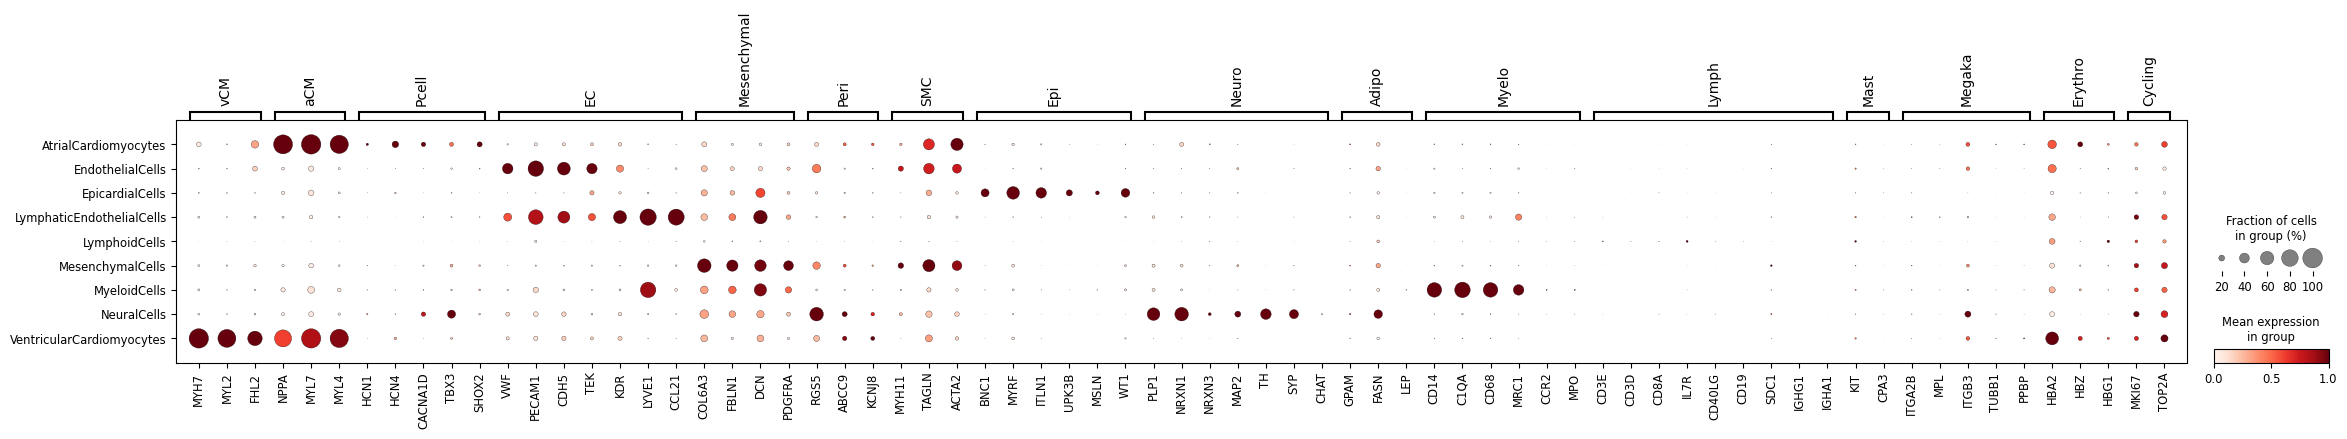

In [9]:
sdata_lognorm = hdscn_sel.copy()
sc.pp.filter_genes(sdata_lognorm, min_cells=3)
sc.pp.normalize_total(sdata_lognorm, target_sum=1e4)
sc.pp.log1p(sdata_lognorm)

marker_genes_dict = {
    'vCM': ['MYH7', 'MYL2', 'FHL2'],
    'aCM': ['NPPA', 'MYL7', 'MYL4'],
    'Pcell':['HCN1','HCN4','CACNA1D','TBX3','SHOX2'],
    'EC': ['VWF', 'PECAM1', 'CDH5','TEK','KDR','LYVE1','CCL21'],
    'Mesenchymal': ['COL6A3','FBLN1','DCN', 'GCN', 'PDGFRA'],
    'Peri': ['RGS5', 'ABCC9', 'KCNJ8'],
    'SMC': ['MYH11', 'TAGLN', 'ACTA2'],
    'Epi':['BNC1','MYRF','ITLN1','UPK3B','MSLN','WT1'],
    'Neuro': ['PLP1', 'NRXN1', 'NRXN3',"TUBB3","MAP2",'TH','SYP','CHAT'],
    'Adipo': ['GPAM', 'FASN', 'LEP'],
    'Myelo': ['CD14', 'C1QA', 'CD68','MRC1','CCR2','MPO'],
    'Lymph': ['CD3E','CD3D','CD8A','IL7R', 'CD40LG','CD19','SDC1','IGHG1','IGHA1'],
    'Mast': ['KIT', 'CPA3'],
    'Megaka':['ITGA2B','MPL','ITGB3', 'TUBB1', 'PPBP'],
    'Erythro':['HBA2','HBZ','HBG1'],
    'Cycling':['MKI67','TOP2A'],
    # 'Mitochondria':['MT-CO1','MT-CO3','MT-CYB','MT-ATP6']
}

for k, v in marker_genes_dict.items():
    marker_genes_dict[k] = [x for x in v if x in sdata_lognorm.var_names]

sc.pl.dotplot(sdata_lognorm, 
              marker_genes_dict, 
              groupby='coarse_grain_tacco_ref-hd-scn',
              dendrogram=False,
              standard_scale="var",
              color_map="Reds",
             # swap_axes=True
             )

In [10]:
hdscn_sel.obs['coarse_grain_tacco_ref-hd-scn'].value_counts()

coarse_grain_tacco_ref-hd-scn
VentricularCardiomyocytes    114538
MesenchymalCells              52703
AtrialCardiomyocytes          34193
EndothelialCells               2878
EpicardialCells                2399
LymphoidCells                  2289
LymphaticEndothelialCells      2169
NeuralCells                    1501
MyeloidCells                   1203
Name: count, dtype: int64

# DEGs

/rfs/project/rfs-iCNyzSAaucw/kk837/miniconda3/envs/TACCO_env/lib/python3.13/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 18066 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


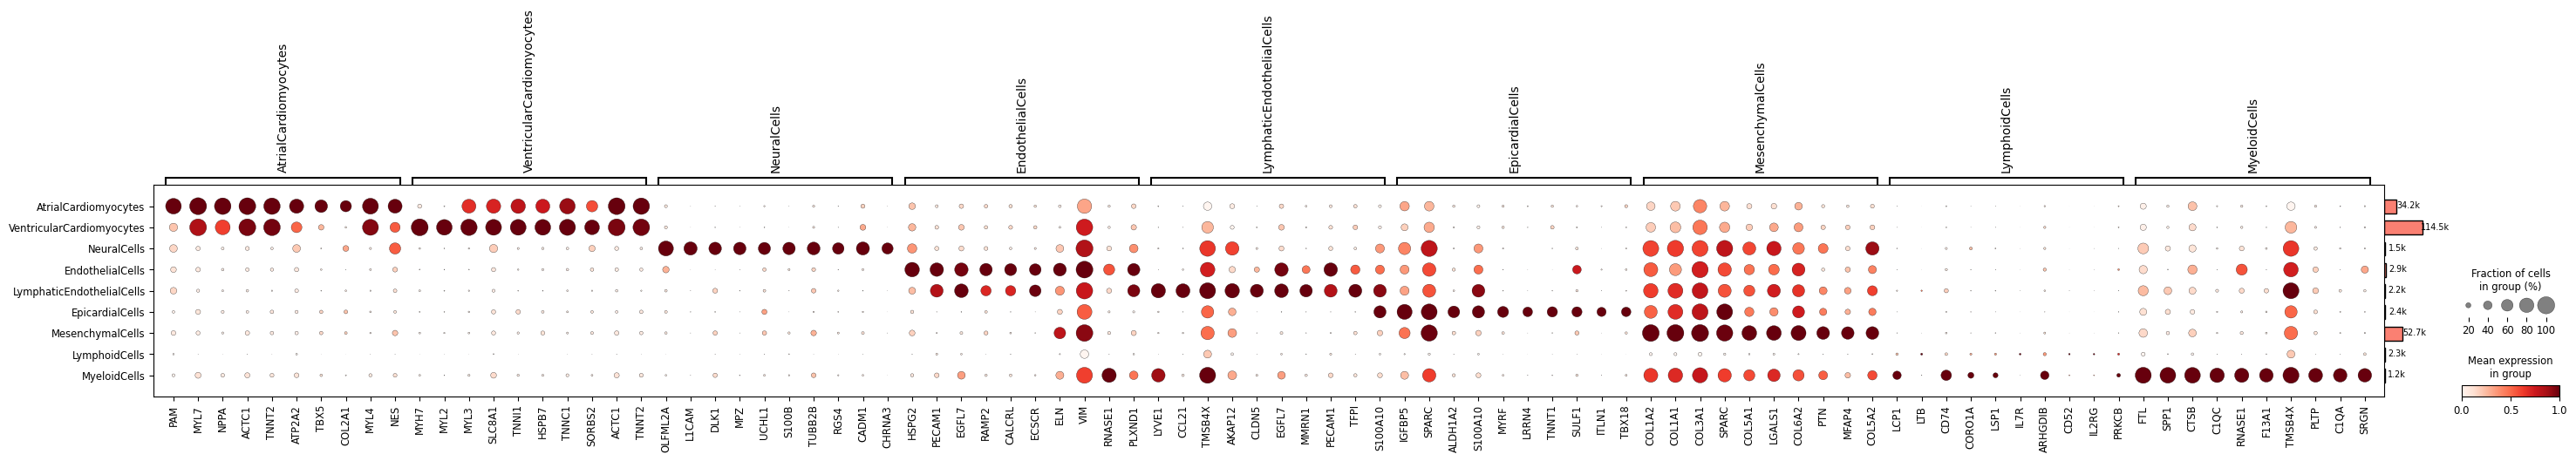

In [11]:
# DEG analysis
groupby = 'coarse_grain_tacco_ref-hd-scn'

sdata_lognorm.uns['log1p']['base']=None
sc.tl.rank_genes_groups(sdata_lognorm,groupby=groupby)
sc.tl.dendrogram(sdata_lognorm, groupby=groupby)
dp=sc.pl.rank_genes_groups_dotplot(sdata_lognorm, dendrogram=True, standard_scale='var', return_fig=True)
dp.add_totals().show()

In [15]:
df = que.obsm['TACCO_ref-HD-SCN'].copy()
df.max(axis=1).reindex(hdscn_sel.obs_names)

index
HEA_FOET14880396___1527                         0.386310
HEA_FOET14880396___3573                         0.701298
HEA_FOET14880396___3598                         0.823902
HEA_FOET14880396___3678                         0.632574
HEA_FOET14880396___3834                         0.445642
                                                  ...   
CellTalkHHD_Human_13_BRC2757-2758-7___287686    0.554888
CellTalkHHD_Human_13_BRC2757-2758-7___288049    0.486212
CellTalkHHD_Human_13_BRC2757-2758-7___288089    0.514146
CellTalkHHD_Human_13_BRC2757-2758-7___288248    0.422562
CellTalkHHD_Human_13_BRC2757-2758-7___288492    0.635431
Length: 213873, dtype: float64

In [20]:
set(hdscn_sel.obs[groupby])

{'AtrialCardiomyocytes',
 'EndothelialCells',
 'EpicardialCells',
 'LymphaticEndothelialCells',
 'LymphoidCells',
 'MesenchymalCells',
 'MyeloidCells',
 'NeuralCells',
 'VentricularCardiomyocytes'}

# Cell composition scores per annotated cell types

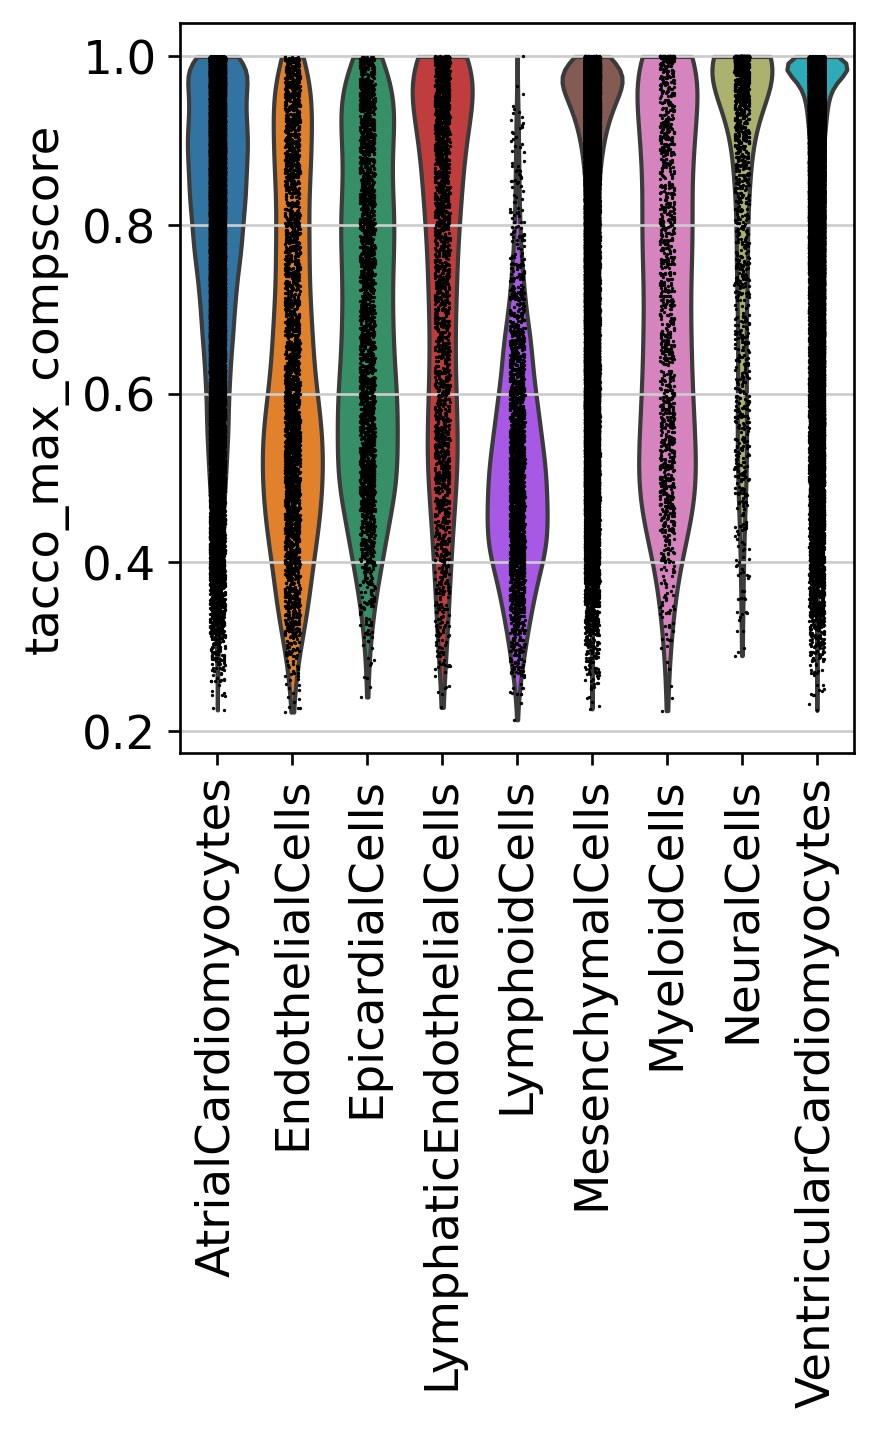

In [22]:
groupby = 'coarse_grain_tacco_ref-hd-scn'

# add max composition score
df = que.obsm['TACCO_ref-HD-SCN'].copy()
hdscn_sel.obs['tacco_max_compscore'] = df.max(axis=1).reindex(hdscn_sel.obs_names)

ax = sc.pl.violin(hdscn_sel, keys='tacco_max_compscore', groupby=groupby,
             rotation=90,show=False)
plt.show()

# Save

In [26]:
print(hdscn_sel.X.data[:10])
hdscn_sel.write(f'{data_object_dir}/TACCO/tacco-splitted_ref-HD-SCN_filtered_raw.h5ad')

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [27]:
f'{data_object_dir}/TACCO/tacco-splitted_ref-HD-SCN_filtered_raw.h5ad'

'/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/tacco-splitted_ref-HD-SCN_filtered_raw.h5ad'

# Marker expressions with only high composition score cells

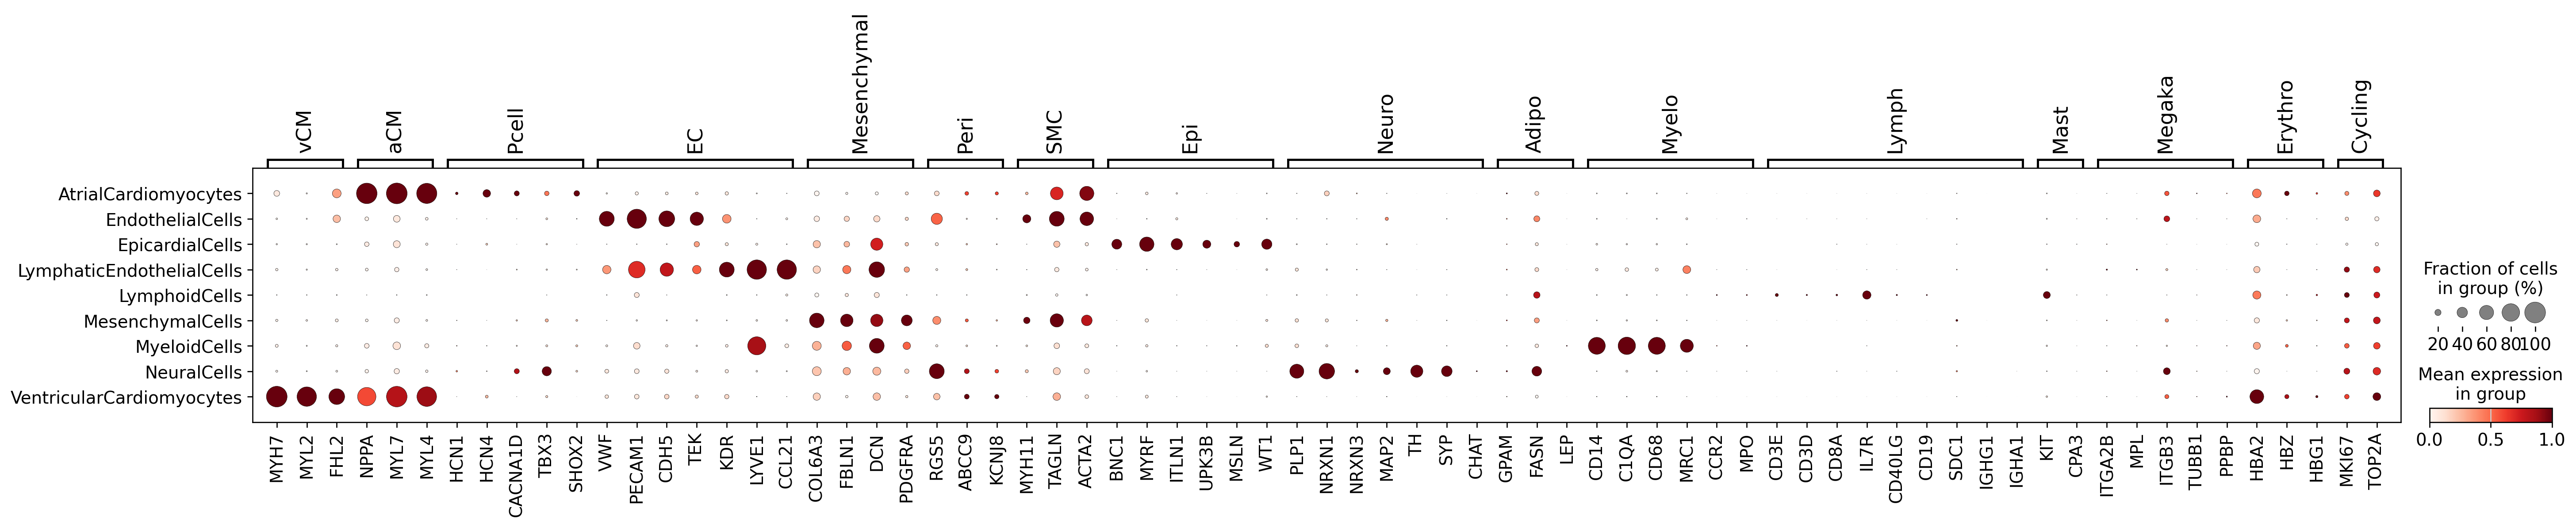

In [24]:
# marker expression with only high composition score cells
score_thresh = 0.7
ad = hdscn_sel[hdscn_sel.obs['tacco_max_compscore']>=score_thresh].copy()

sc.pp.filter_genes(ad, min_cells=3)
sc.pp.normalize_total(ad, target_sum=1e4)
sc.pp.log1p(ad)

marker_genes_dict = {
    'vCM': ['MYH7', 'MYL2', 'FHL2'],
    'aCM': ['NPPA', 'MYL7', 'MYL4'],
    'Pcell':['HCN1','HCN4','CACNA1D','TBX3','SHOX2'],
    'EC': ['VWF', 'PECAM1', 'CDH5','TEK','KDR','LYVE1','CCL21'],
    'Mesenchymal': ['COL6A3','FBLN1','DCN', 'GCN', 'PDGFRA'],
    'Peri': ['RGS5', 'ABCC9', 'KCNJ8'],
    'SMC': ['MYH11', 'TAGLN', 'ACTA2'],
    'Epi':['BNC1','MYRF','ITLN1','UPK3B','MSLN','WT1'],
    'Neuro': ['PLP1', 'NRXN1', 'NRXN3',"TUBB3","MAP2",'TH','SYP','CHAT'],
    'Adipo': ['GPAM', 'FASN', 'LEP'],
    'Myelo': ['CD14', 'C1QA', 'CD68','MRC1','CCR2','MPO'],
    'Lymph': ['CD3E','CD3D','CD8A','IL7R', 'CD40LG','CD19','SDC1','IGHG1','IGHA1'],
    'Mast': ['KIT', 'CPA3'],
    'Megaka':['ITGA2B','MPL','ITGB3', 'TUBB1', 'PPBP'],
    'Erythro':['HBA2','HBZ','HBG1'],
    'Cycling':['MKI67','TOP2A'],
    # 'Mitochondria':['MT-CO1','MT-CO3','MT-CYB','MT-ATP6']
}

for k, v in marker_genes_dict.items():
    marker_genes_dict[k] = [x for x in v if x in sdata_lognorm.var_names]

sc.pl.dotplot(ad, 
              marker_genes_dict, 
              groupby='coarse_grain_tacco_ref-hd-scn',
              dendrogram=False,
              standard_scale="var",
              color_map="Reds",
             # swap_axes=True
             )

/rfs/project/rfs-iCNyzSAaucw/kk837/miniconda3/envs/TACCO_env/lib/python3.13/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 18063 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


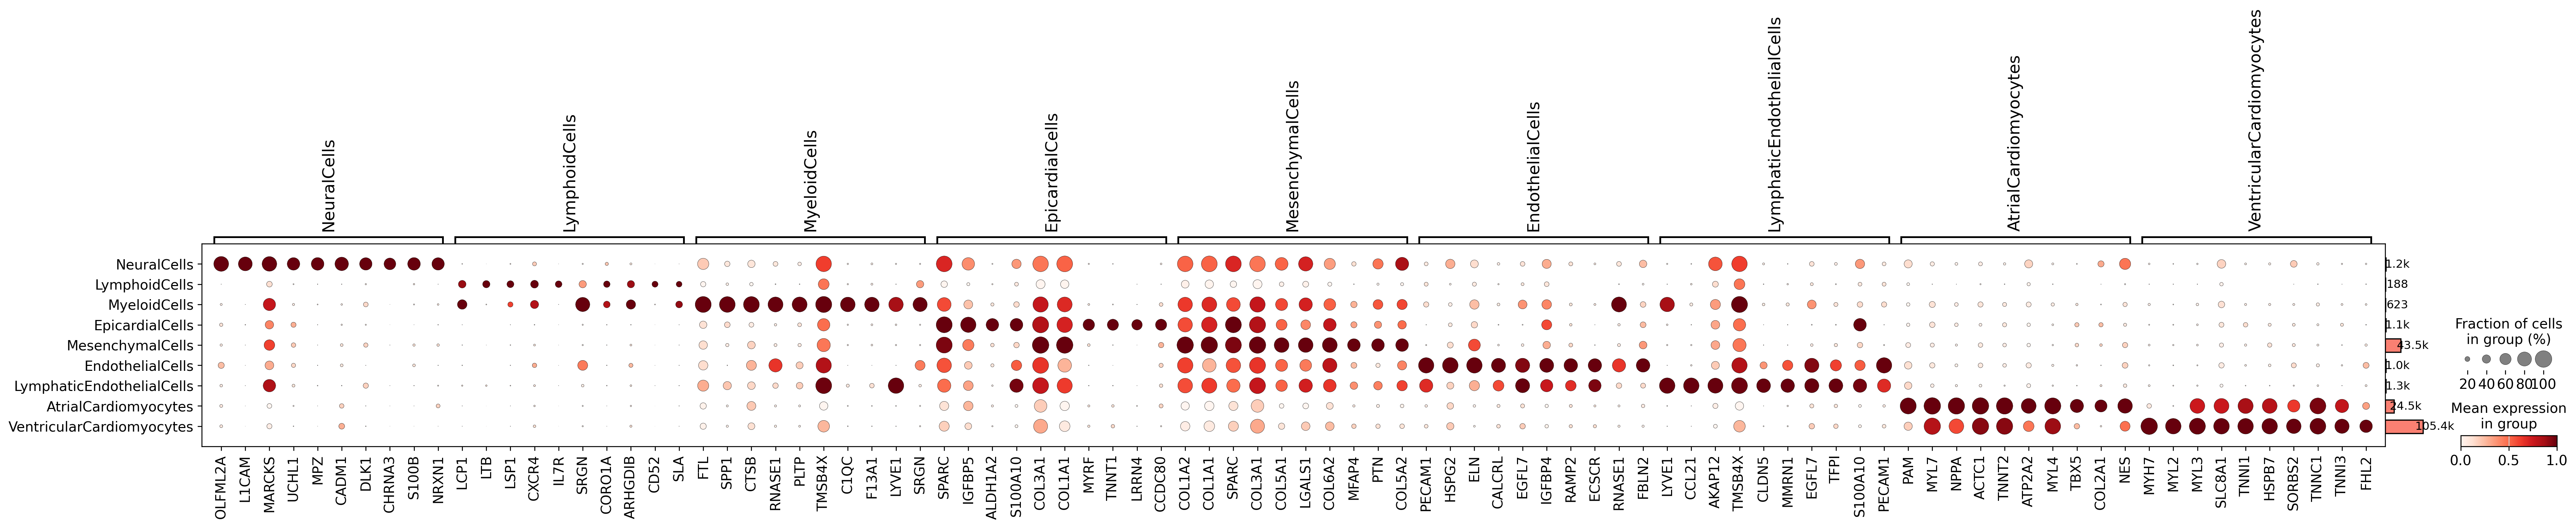

In [25]:
# DEG
# DEG analysis
groupby = 'coarse_grain_tacco_ref-hd-scn'

ad.uns['log1p']['base']=None
sc.tl.rank_genes_groups(ad,groupby=groupby)
sc.tl.dendrogram(ad, groupby=groupby)
dp=sc.pl.rank_genes_groups_dotplot(ad, dendrogram=True, standard_scale='var', return_fig=True)
dp.add_totals().show()